## Przygotowanie

Przed rozpoczęciem pracy z notatnikiem proszę zmienić jego nazwę dodając na początku numer albumu, imię i nazwisko.
{nr_albumu}\_{imię}\_{nazwisko}\_{nazwa}

Po wykonaniu wszystkich zadań proszę przesłać wypełniony notatnik przez platformę ELF za pomocą formularza "Prześlij projekt" w odpowiedniej sekcji. 

## Perceptron liniowy

Klasyfikacja jest dziedziną bardzo popularną i istnieje wiele różnych algorytmów uczenia maszynowego, które służą do rozwiązywania problemów klasyfikacji. My przyjrzymy się działaniu podstawowego algorytmu, jednak jego dobre zrozumienie jest kluczowe do pojęcia bardziej zaawansowanych metod. 

Perceptron, bo o nim będzie mowa w tym notatniku, używany jest do klasyfikacji binarnej. Posiada duże ograniczenie, które mówi, że algorytm jest zbieżny w skończonej liczbie kroków, jeśli zbiór danych jest liniowo separowalny. Co oznacza, że zbiór jest liniowo separowalny? Że próbki należące do różnych klas można oddzielić za pomocą prostej w przypadku dwuwymiarowym, płaszczyzny w przypadku trójwymiarowym i hiperpłaszczyzny w przypadku $N$-wymiarowym.

Spójrzmy jeszcze raz na ankietę prezentującą podział na płeć ze względu na wzrost i wagę.

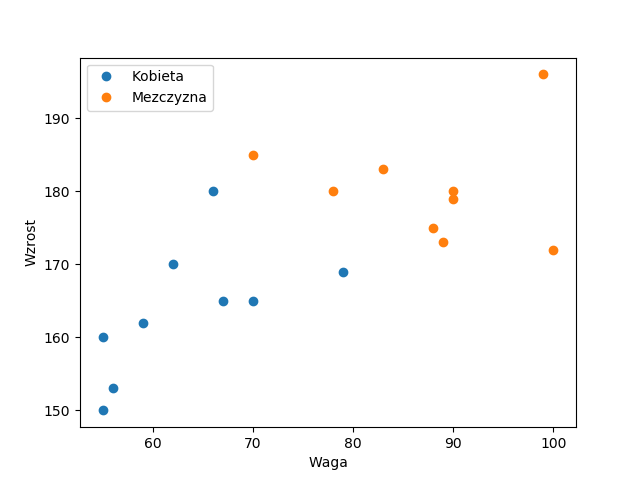

Czy ten zbiór jest liniowo separowalny? Jest, ponieważ jesteśmy w stanie narysować wiele różnych prostych, które oddzielają kobiety od mężczyzn. Zadanie perceptronu właśnie na tym polega, aby znaleźć prostą (w najprostszym przypadku), która oddziela od siebie dwie klasy i na podstawie stworzonego podziału klasyfikować nowe próbki.


### Budowa sztucznego neuronu

Perceptron został stworzony na bazie sztucznego neuronu. Twórcami modelu sztuczego neuronu byli McCulloch i Pitts, którzy w roku 1943 zainspirowani działaniem biologicznego neuronu, zaproponowali jego budowę.


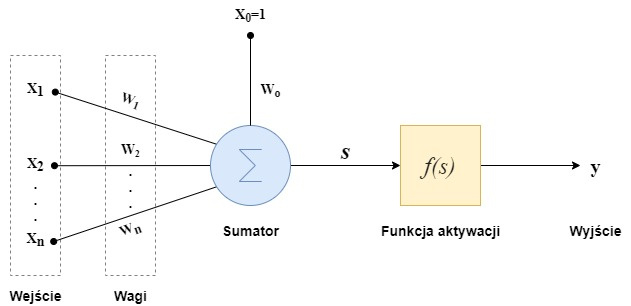

Sztuczny neuron składa się na następujących elementów:

* **Wejście** - warstwa odpowiadająca za przyjmowanie danych wejściowych. Istnieje tyle połączeń do neuronu, ile jest cech w zestawie danych. Przykładowo, jeśli chcemy rozpoznawać płeć na podstawie wagi, wzrostu, długości stopy i długości włosów, to mamy 4 cechy opisujące osobę, więc będą 4 połączenia w warstwie wejściowej.


* **Wagi** - każde połączenie do neuronu ma skojarzoną ze sobą wagę. Wagi są tym, czym były współczynniki regresji w algorytmie regresji. Tutaj przechowywana jest "wiedza" neuronu.


* **Sumator** - element, który odpowiada za zsmumowanie wszystkich iloczynów wejść i wag. Jest to tak zwane pobudzenie neuronu, czyli ważona suma wejść. Do sumatora wchodzi jeszcze jedno dodatkowe połączenie. Na jego wejściu zawsze podawana jest wartość $1$, a waga skojarzona z tym wejściem nazywana jest biasem. Odpowiada ona za przesunięcia prostej separującej klasy. Gdyby jej nie było, prosta ta zawsze przechodziłaby przez początek układu współrzędnych.  


* **Funkcja aktywacji** - pobudzenie neuronu obliczone w sumatorze trafia następnie do funkcji aktywacji. To ona decyduje o zachowaniu neuronu, czyli o jego odpowiedzi. Istnieje wiele różnych funkcji aktywacji, my początkowo wykorzystamy skokową funkcję aktywacji Heaviside’a:

$$ f(s) = \left\{\begin{array}{l}
1, \quad s \geq 0,\\
0, \quad s<0\end{array}\right.$$


* **Wyjście** - odpowiedź neuronu, czyli przetworzona przez funkcje aktywacji ważona suma wejść. W przypadku klasyfikacji binarnej będzie to wartość $0$ lub $1$.

Neuron, który będziemy implementować, ze względu na metodę trenowania i wybraną funkcję aktywacji nazywany jest **perceptronem**. Wzór matematyczny opisujący powyższą budowę perceptronu jest następujący:

$$h_w(x) = f\left(\sum_{i=0}^{n}{w_ix_i}\right)$$

Zgodnie z notacją zaproponowaną przez Prof. Andrew Ng, funkcje, które mapują obserwacje na wynik będziemy nazywać hipotezami (_ang. hypothesis_) i oznaczać jako $h_w(x)$. 
Proszę zauważyć, że we wzorze został uwzględniony bias, czyli waga $w_0$. Na wejście $x_0$ zawsze podawana jest wartość $1$.


### Nauka perceptronu

Istnieją różne metody treningu sztucznego neuronu. Ten, który zaimplementujemy wykorzystywał będzie regułę perceptronową. To prosta metoda, która służy do aktualizacji wag w neuronie ze skokową funkcją aktywacji. Wszystkie wagi perceptronu aktualizowane są jednocześnie po każdej próbce uczącej. Reguła perceptronowa może zostać zapisana jako:

$$
w_{i}=\begin{cases}
w_i,                    &  \ h_w(x^{(k)}) = y^{(k)},\\
w_i + \alpha x_i^{(k)}, &  \ h_w(x^{(k)}) < y^{(k)},\\
w_i - \alpha x_i^{(k)}, &  \ h_w(x^{(k)}) > y^{(k)}
\end{cases}
$$

Gdzie: 
* $y^{(k)}$ jest oczekiwaną odpowiedzą perceptronu (klasą dla $k$-tej próbki uczącej)
* $\alpha$ jest współczynnikiem uczenia i przybiera wartości z przedziału $(0,1)$.

Pamiętajmy, że $h_w(x)$ i $y$ mogą przyjąć tylko wartości $0$ lub $1$. W takim przypadku wszystkie możliwe kombinacje aktualizacji wag wyglądają następująco:

| h_w(x) | y |     aktualizacja wag     |
|:------:|:-:|:------------------------:|
|    0   | 0 |         bez zmian        |
|    0   | 1 | $w_i + \alpha x_i^{(k)}$ |
|    1   | 0 | $w_i - \alpha x_i^{(k)}$ |
|    1   | 1 |         bez zmian        |

Czyli jeśli odpowiedź perceptronu była $0$, a rzeczywista wartość wyniosła $1$, to musimy zwiększyć wagi, aby pobudzenie neuronu miało większą wartość. Jeśli odpowiedź perceptronu była $1$, a rzeczywista wartość $0$, to musimy zmniejszyć wagi, by pobudzenie neuronu miało mniejszą wartość. W pozostałych przypadkach odpowiedzi się zgadzają, więc nie aktualizujemy wag. Dzięki temu prostemu algorytmowi, perceptron zawsze znajdzie prostą separującą klasy w liniowo separowalnym zestawie danych.


### Algorytm perceptronu

Mając już wszystkie potrzebne informacje o działaniu perceptronu, zapiszmy algorytm.

1. Wygenerowanie początkowych wag perceptronu,
2. Wybranie $k$ - tej próbki uczącej ze zbioru danych
3. Obliczenie ważonej sumy wejść dla $k$-tej próbki uczącej,
4. Oblicznie odpowiedzi neuronu poprzez funkcję aktywacji Heaviside’a,
5. Aktualizacja wag zgodnie z regułą perceptronową,
6. Powrót do kroku 2 jeśli k < N, a N to liczba wszystkich próbek uczących,
7. Przerwanie uczenia, jeśli perceptron rozpoznaje wszystkie próbki prawidłowo lub jego błąd mieści się w ustalonym zakresie. W przeciwnym wypadku, ustawienie na k = 0 i powrót do kroku 2.

Przejście przez wszystkie próbki uczące w zestawie danych nazywane jest epoką. Punkt 7 mówi o tym, że jeśli wszystkie próbki w epoce zostały dobrze sklasyfikowane, to możemy przerwać uczenie. Ilość epok potrzebna do treningu perceptronu jest zależna od współczynnika uczenia $\alpha$ oraz od zestawu danych. W zestawach danych, które nie są liniowo separowalne, perceptron nigdy nie będzie miał stuprocentowej skuteczności klasyfikacji. W takich przypadkach dobrze jest zabezpieczyć algorytm przed nieskończonym procesem uczenia.


### Granica decyzyjna

Wiadomo już, że zadaniem perceptronu jest oddzielenie próbek z przeciwnych klas. Prosta, która oddziela próbki z różnych klas nazywana jest granicą decyzyjną. Przed przejściem do implementacji, warto wyrobić sobie pewną intuicję, co to tak naprawdę to oznacza i dlaczego perceptron w ogóle działa.

Załóżmy, że mamy zbiór danych z dwoma cechami $x_1$ i $x_2$. Zbiór ten jest liniowo separowalny. 

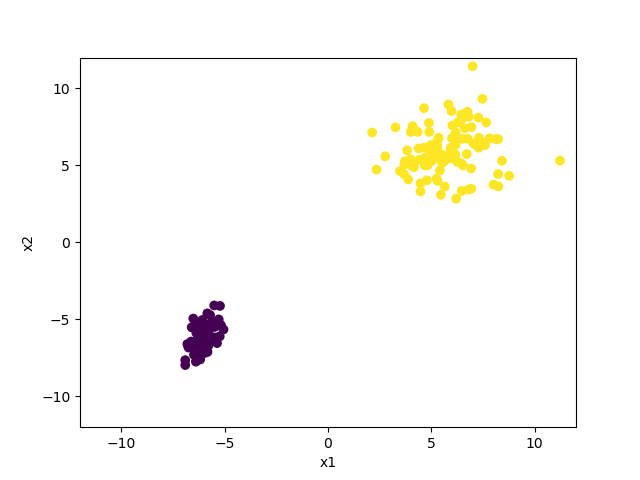
    

W naszym przypadku wzór perceptronu dla dwóch cech wygląda następująco: 

$$h_w(x) = f(w_0x_0 + w_1x_1 + w_2x_2)$$

Spójrzmy jeszcze jak wygląda wykres naszej funkcji aktywacji Heaviside’a, która decyduje o odpowiedzi perceptronu.

<div>
    <img src="attachment:heaviside_function.png" width="60%">
</div>

Analizując wykres, można zauważyć, że odpowiedź $0$ będzie w sytuacji, gdy wartość wchodząca do funkcji aktywacji będzie ujemna, a gdy będzie dodatnia, to odpowiedź będzie równa $1$. Dobrze, czyli wiemy, że żeby perceptron dał predykcję $1$, to ważona suma wejść musi być większa od zera, w przeciwnym przypadku da odpowiedź $0$. Zapiszmy to.

$h_w(x) = 1$ jeśli

$$w_0x_0 + w_1x_1 + w_2x_2 > 0$$ 

$h_w(x) = 0$ jeśli 

$$w_0x_0 + w_1x_1 + w_2x_2 < 0$$ 

Czyli wynika z tego, że zmiana decyzji predykcji jest wtedy, gdy ważona suma będzie równa $0$. Wykres funkcji aktywacji to potwierdza.

$$w_0x_0 + w_1x_1 + w_2x_2 = 0$$


Załóżmy, że za pomocą algorytmu perceptronu znaleźliśmy następujące wartości wag: $[-5, 1, 1]$. Podstawmy te wartości do równania.

$$-5 + 1x_1 + 1x_2 = 0$$ 

Pamiętamy, że $x_0$ ma zawsze wartość $1$, więc pomijamy je w równaniu. Teraz przekształćmy równanie tak, aby po lewej stronie były niewiadome.

$$x_1 + x_2 = 5$$ 
$$x_2 = -x_1 + 5$$

To co otrzymaliśmy, to równanie prostej o współczynniku kierunkowym $-1$. Prosta ta przetnie oś $x_2$ w punkcie $(0,5)$, a oś $x_1$ w punkcie $(5,0)$. Nanieśmy prostą na nasz wykres z zestawem danych.

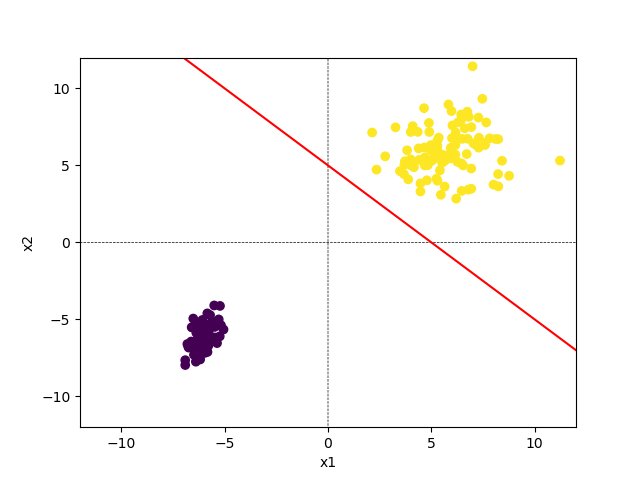

Prosta, którą nanieśliśmy na wykres, to **granica decyzyjna** (ang. decision boundary). Jest to miejsce miejsce, w którym następuje zmiana predykcji. Wszystkie próbki, które znajdą się poniżej prostej będą zaklasyfikowane jako klasa $0$, a te powyżej, jako klasa $1$.


### Jak narysować granicę decyzyjną

Równanie ogólne prostej ma postać $Ax + By + C = 0$

W naszym przypadku: 

$w_{1}x_{1} + w_{2}x_{2} + w_{0}x_{0} = 0$, gdzie $x_{0} = 1$

Dlaczego = $0$? Ponieważ w tym miejscu następuje zmiana decyzji klasyfikacji - zgodnie z wykresem funkcji skokowej Heaviside'a.

Teraz chcemy przekształcić równanie w taki sposób, żeby tylko $x_{2}$ było po lewej stronie stronie równania, czyli chcemy przejść z równania ogólnego prostej na równanie kierunkowe. Dokładnie tak jak się to robiło w szkole średniej np. [przykład](https://zadaniacke.pl/teoria/rownanie-kierunkowe-i-ogolne-prostej/)

$w_{1}x_{1} + w_{2}x_{2} + w_{0}x_{0} = 0$ <- równanie OGÓLNE prostej

$w_{2}x_{2} = -(w_{1}x_{1} + w_{0})$


$x_{2} = \frac{-(w_{1}x_{1} + w_{0})}{w_{2}}$ <- równanie KIERUNKOWE prostej

Mając równanie kierunkowe prostej w łatwy sposób możemy stworzyć rysunek granicy decyzyjnej.

Przykładowy kod tworzący granicę decyzyjną w zadanym przedziale wartości:

```python
import matplotlib.pyplot as plt
import numpy as np

# ustalamy wagi
w = [2, 3, 1.5]

# tworzymy punkty na osi x1
x1 = np.linspace(-5, 5, 100)

# obliczamy x2 (y) dla wszystkich punktów x1 na podstawie wybranych wag
x2 = -(w[1]*x1 + w[0])/w[2]

# podpisujemy osie
plt.xlabel("x1")
plt.ylabel("x2")

# dodajemy dodatkowo osie x i y, żeby wiedzieć gdzie jest punkt 0,0
zeros = np.zeros(100)
plt.plot(x1, zeros, c="black", linewidth=0.5, linestyle='--')
plt.plot(zeros, x1, c="black", linewidth=0.5, linestyle='--')

# ograniczamy widoczność wykresu do zakresu -5, 5 dla obu osi
plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.plot(x1, x2)
plt.show()
```

### Zadanie 1

W pliku o nazwie Ankieta.csv zajdują się dane z omawianej wcześniej ankiety. Każdy rekord zawiera informacje o wzroście oraz wadze, a ostatnią kolumną jest płeć. 

* Zaimplementuj algorym perceptronu, który będzie skutecznie klasyfikował próbki znajdujące się w zestawie danych. Sugerowane jest stworzenie ogólnej implementacji perceptronu, który będzie w stanie rozwiązać problem dla dowolnej ilości cech w zestawie danych.
* Porównaj czasy działania algorytmu dla oryginalnego i znormalizowanego zestawu danych. Jak normalizacja danych wpływa na algorytm perceptronu?

_Uwaga: w zbiorze danych Ankieta.csv kolumna "Plec" ma wartości tekstowe. Przed implementacją konieczne jest przemapowanie ich do postaci liczbowej. Np. Kobieta - 1, Mezczyzna - 0._

In [16]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import os

# Function to load and preprocess the dataset
def load_data(filename):
    # Check if the file exists, raise error if not
    if not os.path.exists(filename):
        raise FileNotFoundError(f"File {filename} doesn't exist!")
    
    # Read the CSV file into a DataFrame
    df = pd.read_csv(filename)
    
    # Ensure the dataset contains the 'plec' column and has at least 3 columns
    if 'plec' not in df.columns or len(df.columns) < 3:
        raise ValueError('Invalid CSV file format.')
    
    # Convert 'plec' column values to numerical: 'Kobieta' -> 1, 'Mezczyzna' -> 0
    df['plec'] = df['plec'].map({'Kobieta': 1, 'Mezczyzna': 0})
    
    # Separate features (X) and target (y)
    x = df.iloc[:, :-1].values  # All columns except the last one are features
    y = df.iloc[:, -1].values   # The last column is the target
    return x, y

# Perceptron class implementation
class Perceptron:
    def __init__(self, learning_rate=0.005, epochs=1000):
        self.learning_rate = learning_rate  # Learning rate for weight updates
        self.epochs = epochs                # Number of training epochs
        self.weights = None                 # Weights initialized later
        self.bias = 0                        # Bias initialized later
        self.history = []                   # To store the weights and bias for visualization

    def fit(self, X, y):
        samples, features = X.shape    # Get the number of samples and features
        self.weights = np.random.uniform(-1, 1, size=features)  # Random initialization of weights
        self.bias = np.random.uniform(-1, 1)  # Random initialization of bias
        
        # Training the perceptron over multiple epochs
        for epoch in range(self.epochs):
            indices = np.random.permutation(samples)  # Shuffle the indices of samples
            
            for idx in indices:
                x_i = X[idx]  # Get the sample at index idx
                linear_output = np.dot(x_i, self.weights) + self.bias  # Compute the linear output
                y_pred = np.where(linear_output >= 0, 1, 0)  # Activation function (step function)
                
                # Update rule: weight update based on the difference between true and predicted label
                update = self.learning_rate * (y[idx] - y_pred)
                self.weights += update * x_i   # Update the weights
                self.bias += update            # Update the bias
            
            # Record the weights and bias at specific intervals (beginning, quarter, half, three-quarters)
            if epoch in [0, self.epochs // 4, self.epochs // 2, 3 * self.epochs // 4]:
                self.history.append((self.weights.copy(), self.bias))

    def predict(self, X):
        # Predict the labels for input samples X
        linear_output = np.dot(X, self.weights) + self.bias  # Compute linear output for all samples
        return np.where(linear_output >= 0, 1, 0)  # Return 1 if output >= 0, else 0

    def accuracy(self, X, y):
        # Calculate the accuracy by comparing predicted labels with actual labels
        y_pred = self.predict(X)
        return np.mean(y_pred == y)  # Mean of correct predictions

# Load the dataset
filename = 'Ankieta.csv'
x, y = load_data(filename)

# Create a perceptron instance
perceptron = Perceptron()
start_time = time.time()  # Start time for training
perceptron.fit(x, y)  # Train the perceptron on original data
end_time = time.time()  # End time after training
original_time = end_time - start_time  # Calculate the elapsed time
print(f'Training time on original data: {original_time:.4f} s')

# Normalize the data (Standardization)
scaler = StandardScaler()
X_normalized = scaler.fit_transform(x)  # Standardize features to have zero mean and unit variance

# Train the perceptron on normalized data
perceptron_normalized = Perceptron()
start_time = time.time()  # Start time for training with normalized data
perceptron_normalized.fit(X_normalized, y)  # Train the perceptron on normalized data
end_time = time.time()  # End time after training
normalized_time = end_time - start_time  # Calculate the elapsed time
print(f'Training time on normalized data: {normalized_time:.4f} s')

# Compare training times
print(f'Normalization sped up the algorithm by {original_time / normalized_time:.2f} times.')


Training time on original data: 0.7871 s
Training time on normalized data: 0.7636 s
Normalization sped up the algorithm by 1.03 times.


### Zadanie 2

Stwórz wykres przedstawiający dane z pliku Ankieta.csv w dwuwymiarowej przestrzeni wraz z granicą decyzyjną obliczoną w poprzednim zadaniu. Dodatkowo, 3 wykresy na których pokażesz jak zmieniała się granica decyzyjna na przestrzeni epok.

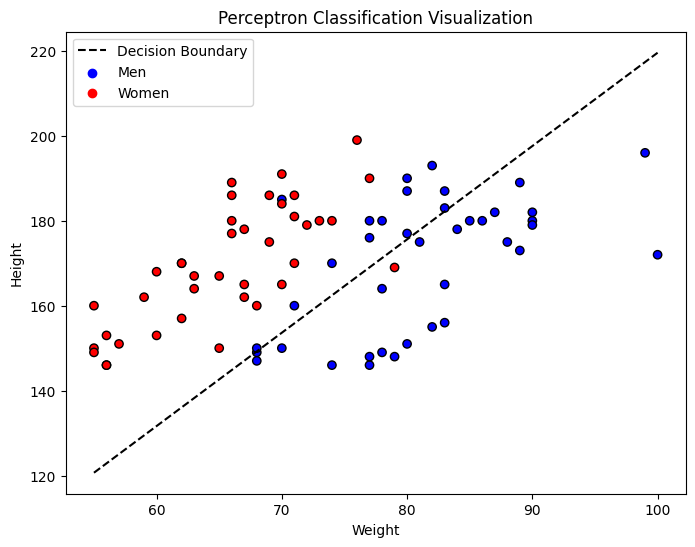

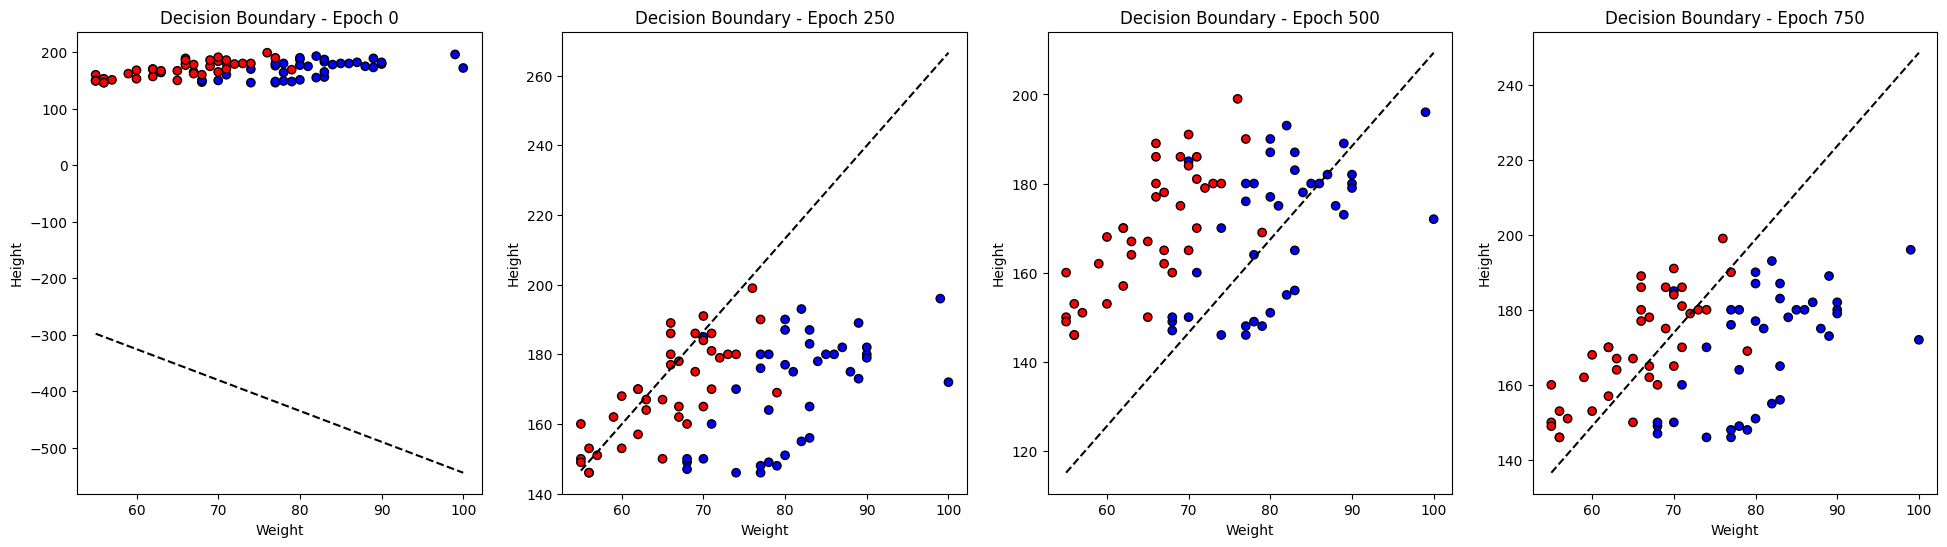

In [17]:
# YOUR CODE HERE

# Visualization of classification results
# Create a scatter plot of the data points, colored by their labels (y), using the 'bwr' colormap for gender (blue for men, red for women)
plt.figure(figsize=(8, 6))  # Set the figure size
plt.scatter(x[:, 0], x[:, 1], c=y, cmap='bwr', edgecolors='k')  # Scatter plot with 'Weight' on x-axis and 'Height' on y-axis
plt.xlabel('Weight')  # Label for x-axis
plt.ylabel('Height')  # Label for y-axis
plt.title('Perceptron Classification Visualization')  # Title for the plot

# Plotting the decision boundary
# Create an array of x-values for the decision boundary plot
x_values = np.linspace(x[:, 0].min(), x[:, 0].max(), 100)  # Generate 100 points evenly spaced between the minimum and maximum of the weight values
# Calculate the corresponding y-values for the decision boundary using the perceptron weights and bias
y_values = -(perceptron.weights[0] * x_values + perceptron.bias) / perceptron.weights[1]
# Plot the decision boundary as a dashed line
plt.plot(x_values, y_values, color='black', linestyle='--', label='Decision Boundary')
# Adding empty scatter points to the legend for "Men" and "Women"
plt.scatter([], [], color='blue', label='Men')  # Add an empty point to the legend for men (blue color)
plt.scatter([], [], color='red', label='Women')  # Add an empty point to the legend for women (red color)
plt.legend()  # Show the legend
plt.show()  # Display the plot

# Visualization of the decision boundary changes over time (during training)
# Create subplots to visualize the changes in the decision boundary during training at different epochs
fig, axes = plt.subplots(1, 4, figsize=(24, 6))  # Create a 1-row, 4-column grid of subplots

# Loop over the saved weights and bias at different epochs (from perceptron.history)
for i, (weights, bias) in enumerate(perceptron.history):
    # Calculate the corresponding y-values for the decision boundary at the current epoch
    y_values = -(weights[0] * x_values + bias) / weights[1]
    # Plot the data points and the decision boundary for the current epoch
    axes[i].scatter(x[:, 0], x[:, 1], c=y, cmap='bwr', edgecolors='k')
    axes[i].plot(x_values, y_values, color='black', linestyle='--')  # Plot the decision boundary
    axes[i].set_xlabel('Weight')  # Label for x-axis
    axes[i].set_ylabel('Height')  # Label for y-axis
    axes[i].set_title(f'Decision Boundary - Epoch {(i) * (perceptron.epochs // 4)}')  # Title indicating the epoch number

# Show the plot with all subplots
plt.show()


### Zadanie 3

Stwórz wykresy dla różnych współczynników uczenia alpha. Jakie widzisz zależności?

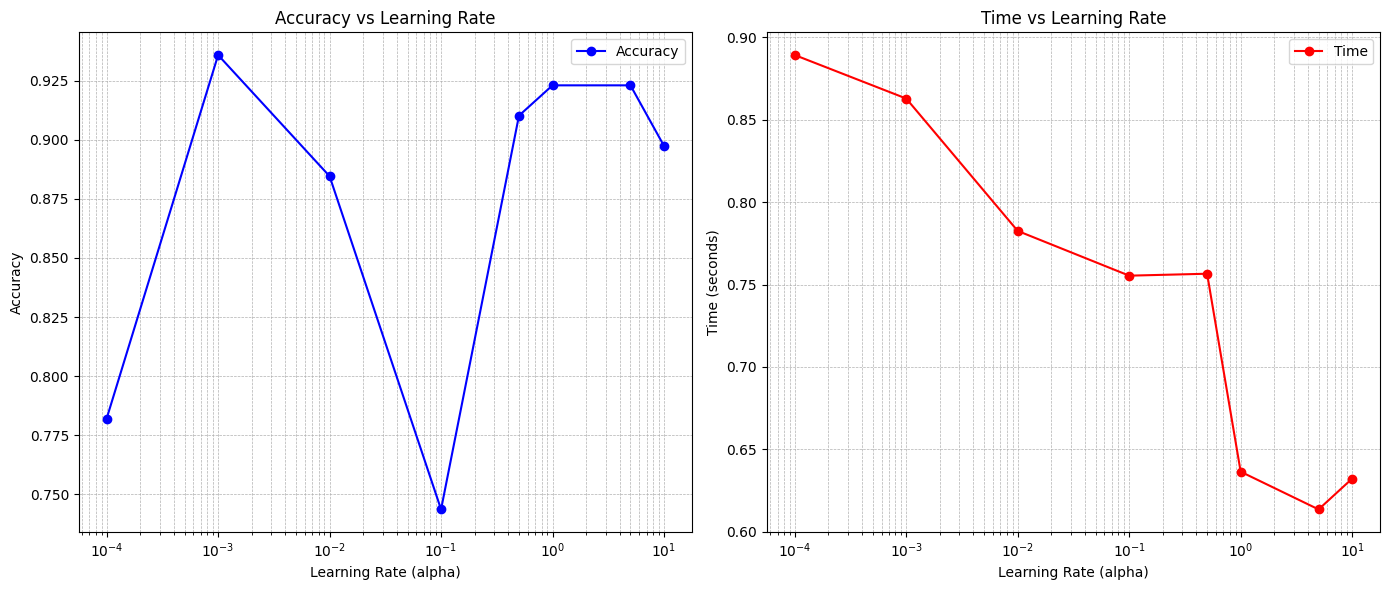

In [18]:
# YOUR CODE HERE

# Function to test different learning rates and generate plots
def test_learning_rates(X, y, learning_rates, epochs=1000):
    accuracies = []  # List to store accuracy for each learning rate
    times = []  # List to store time taken for training for each learning rate
    
    # Loop over each learning rate in the provided list
    for lr in learning_rates:
        perceptron = Perceptron(learning_rate=lr, epochs=epochs)  # Create a perceptron with the current learning rate
        start_time = time.time()  # Record the start time of training
        perceptron.fit(X, y)  # Train the perceptron on the given data
        end_time = time.time()  # Record the end time of training
        
        accuracy = perceptron.accuracy(X, y)  # Calculate accuracy on the training data
        elapsed_time = end_time - start_time  # Calculate the total training time
        
        accuracies.append(accuracy)  # Append accuracy to the list
        times.append(elapsed_time)  # Append time taken to the list
    
    # Create a figure with two subplots (accuracy plot and time plot)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Plot accuracy vs learning rate
    ax1.plot(learning_rates, accuracies, marker='o', color='b', linestyle='-', label='Accuracy')  # Plot accuracy as a line graph
    ax1.set_xscale('log')  # Set x-axis to logarithmic scale for better visualization
    ax1.set_title('Accuracy vs Learning Rate')  # Title for accuracy plot
    ax1.set_xlabel('Learning Rate (alpha)')  # Label for x-axis
    ax1.set_ylabel('Accuracy')  # Label for y-axis
    ax1.legend()  # Display legend
    ax1.grid(True, which='both', linestyle='--', linewidth=0.5)  # Add grid lines to the plot
    
    # Plot time vs learning rate
    ax2.plot(learning_rates, times, marker='o', color='r', linestyle='-', label='Time')  # Plot time as a line graph
    ax2.set_xscale('log')  # Set x-axis to logarithmic scale
    ax2.set_title('Time vs Learning Rate')  # Title for time plot
    ax2.set_xlabel('Learning Rate (alpha)')  # Label for x-axis
    ax2.set_ylabel('Time (seconds)')  # Label for y-axis
    ax2.legend()  # Display legend
    ax2.grid(True, which='both', linestyle='--', linewidth=0.5)  # Add grid lines to the plot
    
    plt.tight_layout()  # Adjust spacing between subplots to avoid overlap
    plt.show()  # Display the plots

# Test different learning rates
learning_rates = [0.0001, 0.001, 0.01, 0.1, 0.5, 1, 5, 10]  # List of learning rates to test
test_learning_rates(x, y, learning_rates)  # Call the function with the test data and learning rates


### Zadanie 4

Oblicz skuteczność predykcji perceptronu

In [19]:
# YOUR CODE HERE

# Accuracy function to compute the performance of the perceptron
def accuracy(self, X, y):
    # Predict the labels using the perceptron model
    y_pred = self.predict(X)
    # Return the mean of the comparison between predicted labels and actual labels
    return np.mean(y_pred == y)

# Accuracy on the original data (before normalization)
# Calculate and print the accuracy of the perceptron model on the original (non-normalized) data
print(f'Accuracy on original data: {perceptron.accuracy(x, y) * 100:.2f}%')

# Accuracy on the normalized data (after normalization)
# Calculate and print the accuracy of the perceptron model on the normalized data
print(f'Accuracy on normalized data: {perceptron_normalized.accuracy(X_normalized, y) * 100:.2f}%')


Accuracy on original data: 82.05%
Accuracy on normalized data: 97.44%


### Zadanie 5

Spróbuj użyć innej funkcji aktywacji (Relu). Jakie widzisz różnice jakie podobieństwa?

In [20]:
# YOUR CODE HERE

class PerceptronReLU:
    def __init__(self, learning_rate=0.005, epochs=1000):
        self.learning_rate = learning_rate  # Learning rate for weight updates
        self.epochs = epochs  # Number of training epochs
        self.weights = None  # Initialize weights to None, will be set during training
        self.bias = 0  # Initialize bias to 0
        self.history = []  # To store the weights and bias at specific epochs for visualization

    def relu(self, x):
        return np.maximum(0, x)  # ReLU activation: returns 0 for negative values, x for positive values

    def fit(self, X, y):
        samples, features = X.shape  # Get the number of samples and features in the dataset
        self.weights = np.random.uniform(-1, 1, size=features)  # Initialize weights randomly in the range [-1, 1]
        self.bias = np.random.uniform(-1, 1)  # Initialize bias randomly
        
        # Train the perceptron over multiple epochs
        for epoch in range(self.epochs):
            indices = np.random.permutation(samples)  # Shuffle the indices to ensure random training order
            
            # Update weights and bias for each sample in the shuffled data
            for idx in indices:
                x_i = X[idx]  # Current sample
                linear_output = np.dot(x_i, self.weights) + self.bias  # Compute linear output
                y_pred = self.relu(linear_output)  # Apply ReLU activation instead of step function
                
                # Update rule for weights and bias (ReLU outputs continuous values, so threshold to 0/1)
                update = self.learning_rate * (y[idx] - (y_pred > 0).astype(int))  # Convert ReLU output to binary
                self.weights += update * x_i  # Update weights
                self.bias += update  # Update bias
            
            # Save weights and bias at specific epochs for visualization
            if epoch in [0, self.epochs // 4, self.epochs // 2, 3 * self.epochs // 4]:
                self.history.append((self.weights.copy(), self.bias))

    def predict(self, X):
        # Compute the linear output and apply ReLU to get predictions
        linear_output = np.dot(X, self.weights) + self.bias
        return (self.relu(linear_output) > 0).astype(int)  # Return 1 if ReLU output is positive, else 0

    def accuracy(self, X, y):
        # Calculate the accuracy of the model
        y_pred = self.predict(X)  # Get the model predictions
        return np.mean(y_pred == y)  # Calculate the percentage of correct predictions


# Testing the perceptron with ReLU activation function
perceptron_relu = PerceptronReLU()  # Create an instance of the PerceptronReLU class
start_time = time.time()  # Record the start time for training
perceptron_relu.fit(x, y)  # Train the perceptron on the original data (x, y)
end_time = time.time()  # Record the end time for training
relu_time = end_time - start_time  # Calculate the total training time
print(f'Training time of Perceptron with ReLU: {relu_time:.4f} s')  # Print the training time

# Print the accuracy of the perceptron with ReLU on the original data
print(f'Accuracy of Perceptron with ReLU: {perceptron_relu.accuracy(x, y) * 100:.2f}%')

# Print the previously calculated normalized training time and accuracy for comparison
print(f'Training time on normalized data: {normalized_time:.4f} s')  # Normalized data training time
print(f'Accuracy on normalized data: {perceptron_normalized.accuracy(X_normalized, y) * 100:.2f}%')  # Normalized data accuracy


Training time of Perceptron with ReLU: 0.7853 s
Accuracy of Perceptron with ReLU: 89.74%
Training time on normalized data: 0.7636 s
Accuracy on normalized data: 97.44%


### Zadanie 6

Spróbuj zaimplementować inne warunek wykonania pętli uczącej. Który znajduje rozwiązanie najszybciej?

In [21]:
# YOUR CODE HERE    

# Class Definitions

class PerceptronNoWeightChange:
    def __init__(self, learning_rate=0.005, epochs=1000):
        self.learning_rate = learning_rate  # Learning rate for weight updates
        self.epochs = epochs  # Number of training epochs
        self.weights = None  # Initialize weights to None, will be set during training
        self.bias = 0  # Initialize bias to 0
    
    def fit(self, X, y):
        samples, features = X.shape  # Get the number of samples and features in the dataset
        self.weights = np.random.uniform(-1, 1, size=features)  # Initialize weights randomly
        self.bias = np.random.uniform(-1, 1)  # Initialize bias randomly
        prev_weights = np.copy(self.weights)  # Save the initial weights
        
        # Training loop
        for epoch in range(self.epochs):
            indices = np.random.permutation(samples)  # Shuffle the indices to ensure random training order
            for idx in indices:
                x_i = X[idx]  # Current sample
                linear_output = np.dot(x_i, self.weights) + self.bias  # Compute linear output
                y_pred = np.where(linear_output >= 0, 1, 0)  # Apply step activation function

                # Update rule for weights and bias
                update = self.learning_rate * (y[idx] - y_pred)  # Update term based on error
                self.weights += update * x_i  # Update weights
                self.bias += update  # Update bias
                
            # Check if the weights have converged (i.e., no significant change)
            if np.allclose(self.weights, prev_weights):  # Compare if weights have changed
                print("Convergence of weights reached.")  # Print convergence message
                break
            prev_weights = np.copy(self.weights)  # Save the updated weights for the next iteration

    def predict(self, X):
        # Compute the linear output and apply the step function to get predictions
        linear_output = np.dot(X, self.weights) + self.bias
        return np.where(linear_output >= 0, 1, 0)  # Return 1 for positive outputs, else 0

    def accuracy(self, X, y):
        # Calculate the accuracy of the model by comparing predicted and actual labels
        y_pred = self.predict(X)
        return np.mean(y_pred == y)  # Return the percentage of correct predictions


class PerceptronNoErrors:
    def __init__(self, learning_rate=0.005, epochs=1000):
        self.learning_rate = learning_rate  # Learning rate for weight updates
        self.epochs = epochs  # Number of training epochs
        self.weights = None  # Initialize weights to None, will be set during training
        self.bias = 0  # Initialize bias to 0
    
    def fit(self, X, y):
        samples, features = X.shape  # Get the number of samples and features in the dataset
        self.weights = np.random.randn(features)  # Initialize weights randomly
        self.bias = np.random.randn()  # Initialize bias randomly
        
        # Training loop
        for epoch in range(self.epochs):
            indices = np.random.permutation(samples)  # Shuffle the indices to ensure random training order
            errors = 0  # Track number of errors during this epoch
            for idx in indices:
                x_i = X[idx]  # Current sample
                linear_output = np.dot(x_i, self.weights) + self.bias  # Compute linear output
                y_pred = np.where(linear_output >= 0, 1, 0)  # Apply step activation function

                # Update rule for weights and bias
                update = self.learning_rate * (y[idx] - y_pred)  # Update term based on error
                self.weights += update * x_i  # Update weights
                self.bias += update  # Update bias
                
                # Count errors
                if y_pred != y[idx]:
                    errors += 1  # Increment error count if prediction is incorrect
                    
            # Stop training if no errors in classification
            if errors == 0:  
                print("No classification errors.")  # Print message if no errors found
                break

    def predict(self, X):
        # Compute the linear output and apply the step function to get predictions
        linear_output = np.dot(X, self.weights) + self.bias
        return np.where(linear_output >= 0, 1, 0)  # Return 1 for positive outputs, else 0

    def accuracy(self, X, y):
        # Calculate the accuracy of the model by comparing predicted and actual labels
        y_pred = self.predict(X)
        return np.mean(y_pred == y)  # Return the percentage of correct predictions


class PerceptronNoMSEChange:
    def __init__(self, learning_rate=0.005, epochs=1000, tolerance=1e-10):
        self.learning_rate = learning_rate  # Learning rate for weight updates
        self.epochs = epochs  # Number of training epochs
        self.tolerance = tolerance  # Tolerance level for MSE change detection
        self.weights = None  # Initialize weights to None, will be set during training
        self.bias = 0  # Initialize bias to 0
    
    def fit(self, X, y):
        samples, features = X.shape  # Get the number of samples and features in the dataset
        self.weights = np.random.randn(features)  # Initialize weights randomly
        self.bias = np.random.randn()  # Initialize bias randomly
        
        prev_mse = float('inf')  # Initialize previous MSE to a large value
        
        # Training loop
        for epoch in range(self.epochs):
            indices = np.random.permutation(samples)  # Shuffle the indices to ensure random training order
            mse = 0  # Initialize the mean squared error (MSE) for this epoch
            for idx in indices:
                x_i = X[idx]  # Current sample
                linear_output = np.dot(x_i, self.weights) + self.bias  # Compute linear output
                y_pred = np.where(linear_output >= 0, 1, 0)  # Apply step activation function
                
                mse += (y[idx] - y_pred) ** 2  # Calculate the squared error for this sample
                update = self.learning_rate * (y[idx] - y_pred)  # Update term based on error
                self.weights += update * x_i  # Update weights
                self.bias += update  # Update bias
            
            mse /= samples  # Calculate the average MSE for this epoch
            
            # Stop training if the change in MSE is smaller than the tolerance
            if abs(prev_mse - mse) < self.tolerance:  
                print("No significant change in MSE.")  # Print message if MSE change is negligible
                break
            prev_mse = mse  # Save the current MSE for the next iteration

    def predict(self, X):
        # Compute the linear output and apply the step function to get predictions
        linear_output = np.dot(X, self.weights) + self.bias
        return np.where(linear_output >= 0, 1, 0)  # Return 1 for positive outputs, else 0

    def accuracy(self, X, y):
        # Calculate the accuracy of the model by comparing predicted and actual labels
        y_pred = self.predict(X)
        return np.mean(y_pred == y)  # Return the percentage of correct predictions


# Testing the perceptron with the condition "No weight changes"
perceptron_no_weight_change = PerceptronNoWeightChange()
start_time = time.time()  # Start measuring time for training
perceptron_no_weight_change.fit(x, y)  # Train the perceptron on the dataset
end_time = time.time()  # Stop measuring time
print(f"Training time (No weight changes): {end_time - start_time:.4f} s")  # Print training time
print(f"Accuracy: {perceptron_no_weight_change.accuracy(x, y) * 100:.2f}%")  # Print accuracy of the model

# Testing the perceptron with the condition "No classification errors"
perceptron_no_errors = PerceptronNoErrors()
start_time = time.time()  # Start measuring time for training
perceptron_no_errors.fit(x, y)  # Train the perceptron on the dataset
end_time = time.time()  # Stop measuring time
print(f"Training time (No classification errors): {end_time - start_time:.4f} s")  # Print training time
print(f"Accuracy: {perceptron_no_errors.accuracy(x, y) * 100:.2f}%")  # Print accuracy of the model

# Testing the perceptron with the condition "No change in MSE"
perceptron_no_mse_change = PerceptronNoMSEChange()
start_time = time.time()  # Start measuring time for training
perceptron_no_mse_change.fit(x, y)  # Train the perceptron on the dataset
end_time = time.time()  # Stop measuring time
print(f"Training time (No change in MSE): {end_time - start_time:.4f} s")  # Print training time
print(f"Accuracy: {perceptron_no_mse_change.accuracy(x, y) * 100:.2f}%")  # Print accuracy of the model


Training time (No weight changes): 0.8739 s
Accuracy: 79.49%
Training time (No classification errors): 1.0793 s
Accuracy: 78.21%
No significant change in MSE.
Training time (No change in MSE): 0.0262 s
Accuracy: 84.62%


### Zadanie 7

Wykorzystaj stworzony algorym w celu znalezienia granicy decyzyjnej będącej płaszczyzną w trójwymiarowej przestrzeni. Zbiór danych znajduje się w pliku o nazwie 3D_perceptron.csv. Stwórz wykres analogicznie jak w zadaniu 2.

Accuracy on 3D data: 100.00%


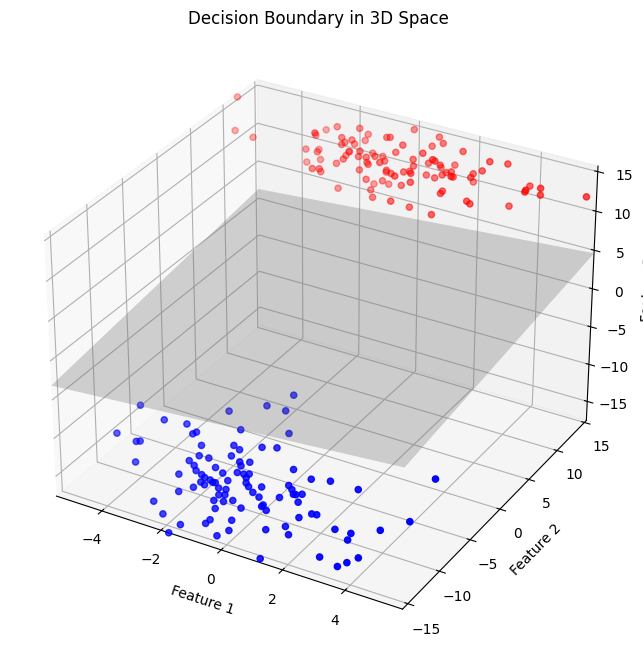

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Function to load 3D data from a CSV file
filename = '3D_perceptron.csv'  # Make sure the file is in the correct location

def load_3d_data(filename):
    # Read the CSV file
    df = pd.read_csv(filename)
    
    # Check if the CSV has exactly 4 columns (3 features and 1 label)
    if len(df.columns) != 4:
        raise ValueError('CSV file should contain 3 features and 1 label.')
    
    # Assuming the data is in the format: x1, x2, x3, y
    X = df.iloc[:, :-1].values  # Features (x1, x2, x3)
    y = df.iloc[:, -1].values   # Label (y)
    return X, y

# Load the 3D data from the file
X, y = load_3d_data(filename)

# Train the Perceptron on the 3D data
perceptron_3d = Perceptron()  # Initialize Perceptron
perceptron_3d.fit(X, y)  # Fit the perceptron model with the data

# Check the accuracy of the perceptron on the 3D data
accuracy = perceptron_3d.accuracy(X, y)
print(f'Accuracy on 3D data: {accuracy * 100:.2f}%')

# Generate a grid of points in the 3D feature space
x1_vals = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)  # Create linearly spaced values for feature x1
x2_vals = np.linspace(X[:, 1].min(), X[:, 1].max(), 100)  # Create linearly spaced values for feature x2
x3_vals = np.linspace(X[:, 2].min(), X[:, 2].max(), 100)  # Create linearly spaced values for feature x3

# Create a mesh grid of points for the decision boundary visualization
x1_grid, x2_grid = np.meshgrid(x1_vals, x2_vals)  # Generate a 2D grid from x1 and x2 values

# Calculate the corresponding x3 values using the decision boundary equation
# Rearranging the linear equation: w1*x1 + w2*x2 + w3*x3 + b = 0
# Solve for x3: x3 = -(w1*x1 + w2*x2 + b) / w3
x3_grid = -(perceptron_3d.weights[0] * x1_grid + perceptron_3d.weights[1] * x2_grid + perceptron_3d.bias) / perceptron_3d.weights[2]

# 3D Visualization of the decision boundary and data points
fig = plt.figure(figsize=(12, 8))  # Increase the figure size for better visualization
ax = fig.add_subplot(111, projection='3d')  # Create a 3D plot

# Plot the data points in 3D space
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=y, cmap='bwr', marker='o')  # Scatter plot with color mapping for labels

# Plot the decision boundary (plane) as a surface
ax.plot_surface(x1_grid, x2_grid, x3_grid, color='gray', alpha=0.3, rstride=100, cstride=100)

# Set axis labels
ax.set_xlabel('Feature 1')  # Label for x-axis (Feature 1)
ax.set_ylabel('Feature 2')  # Label for y-axis (Feature 2)
ax.set_zlabel('Feature 3')  # Label for z-axis (Feature 3)
ax.set_title('Decision Boundary in 3D Space')  # Title for the plot

# Set axis limits based on the feature data
ax.set_xlim(X[:, 0].min(), X[:, 0].max())  # X-axis limits
ax.set_ylim(X[:, 1].min(), X[:, 1].max())  # Y-axis limits
ax.set_zlim(X[:, 2].min(), X[:, 2].max())  # Z-axis limits

# Display the plot
plt.show()
